## Objetivo

O objetivo deste notebook é realizar uma análise exploratória do dataset tanto para obter insights, quanto para mapear os tratamentos a serem realizados durante a transformação dos dados.

## Imports iniciais

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Carregando o arquivo

In [2]:
df = pd.read_csv('../data/raw/dataset.csv', sep=',')

In [3]:
df.head(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Análises Exploratória

### Verificando a saúde dos dados

In [6]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

Investigando os valores nulos, encontramos que há apenas uma ocorrência, entado nas colunas "artists", "album_name" e "track_name".

In [8]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Existem várias faixas que se repetem mais de uma vez. Removeremos essas faixas durante o tratamento.

In [35]:
df['track_id'].value_counts()

track_id
6S3JlDAGk3uu3NtZbPnuhS    9
2Ey6v4Sekh3Z0RUSISRosD    8
2kkvB3RNRzwjFdGhaUA0tz    8
2vU6bm5hVF2idVknGzqyPL    7
5ZsAhuQ24mWHiduaxJqnhW    7
                         ..
5wMkhfu3oYYmFimOGzeFt2    1
64BdW5aHuB3C0QP3qjBJVi    1
1pBc7W7UQacUeQ6kBVlN9f    1
39So2wAM6l3XKWDf5XjiIz    1
5C4IiPTy5cR7lDkXgHHIpb    1
Name: count, Length: 89741, dtype: int64

### Análise univariada na coluna "popularity"

A coluna de popularidade (popularity), indica o quão popular uma faixa no dataset é. Seus valores vão de 0 a 100.

Ao analisar a coluna, temos alguns insights:

1. 25% do dataset é composto por músicas que não são muito ouvidas (popularidade entre 0 e 17).
2. Não temos músicas muito populares distorcendo a média para cima, já que a média (33.2) e a mediana (35) estão bem próximas.
3. Músicas com popularidade acima de 50, já pertencem ao grupo das 25% músicas mais ouvidas do dataset.

In [9]:
df['popularity'].describe()

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

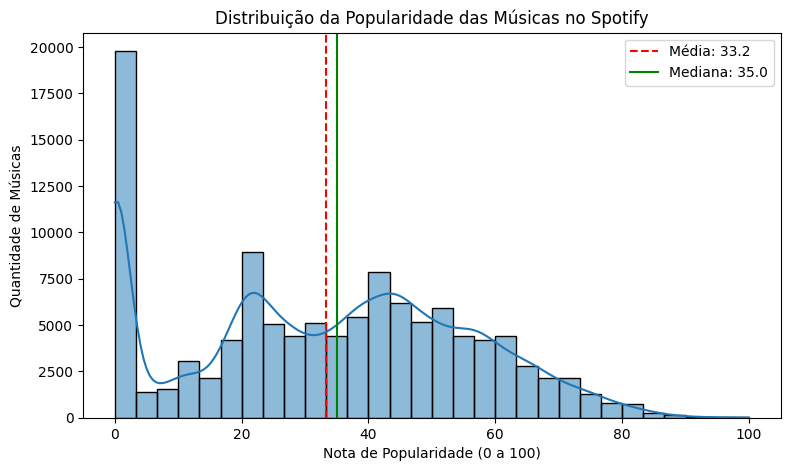

In [13]:
plt.figure(figsize=(9, 5))

sns.histplot(data=df, x='popularity', bins=30, kde=True)

plt.axvline(df['popularity'].mean(), color='red', linestyle='--', label=f"Média: {df['popularity'].mean():.1f}")
plt.axvline(df['popularity'].median(), color='green', linestyle='-', label=f"Mediana: {df['popularity'].median():.1f}")

plt.title('Distribuição da Popularidade das Músicas no Spotify')
plt.xlabel('Nota de Popularidade (0 a 100)')
plt.ylabel('Quantidade de Músicas')
plt.legend()
plt.show()

### Analise univariada na coluna "duration"

A coluna de duração (duration), possui a duração das faixas em milissegundos. Para facilitar a análise nesta coluna, foi realizada uma conversão para minutos.

In [17]:
df['duration_min'] = df['duration_ms'] / 60000

Ao analisar essa coluna. temos que:

1. Existem faixas com a duração zerada. Isso pode significar erro na extração dos dados. Para resovler, definiremos um valor minímo em que as faixas devem estar para continuarem no dataset.
2. A maior faixa possui 87 minutos de duração, quase 1h30. Essa faixa pode na verdade ser algum podcast, ou alguma faixa que é a junção de outras.
3. A maioria das músicas dura entre 3 e 4 minutos e meio.

In [19]:
df['duration_min'].describe().round(2)

count    114000.00
mean          3.80
std           1.79
min           0.00
25%           2.90
50%           3.55
75%           4.36
max          87.29
Name: duration_min, dtype: float64

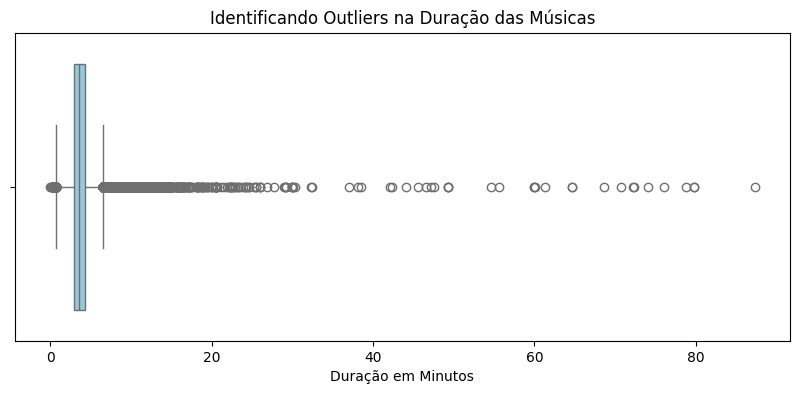

In [20]:
plt.figure(figsize=(10, 4))

sns.boxplot(data=df, x='duration_min', color='skyblue')

plt.title('Identificando Outliers na Duração das Músicas')
plt.xlabel('Duração em Minutos')
plt.show()

### Análise bivariada nas colunas "danceability", "energy" e "valence"

Agora, vamos cruzar três colunas para identificar os tipos de música existentes. As colunas são:
- danceability (0,0 - 1,0) - Descreve o queão adequada uma música é para dançar.
- energy (0,0 - 1,0) - Representa uma percepção de intensidade e atividade.
- valence (0,0 - 1,0) - Descreve a positivade muisical transmitida por uma faixa.

Com a plotagem do gráfico abaixo, temos que:

1. Músicas que são muiito alegres/positivas (alta valência), mas extremamente calmas/lentas (baixa energia) são raras no dataset. Isso faz sentido já que, quando algum artista que transmitir uma vibe mais feliz, o seu ritmo é mais agitado.
2. A maior parte das faixas são de alta energia, independente se são tristes ou alegres.
3. O canto superior direito, representa os hits que pop de rádio, dance music, etc. Enquanto do outro lado, no canto superior extremo esquerdo, são músicas com uma energia máxima, mas valência baixa, podendo indicar músicas de Rock agressivo ou raps, que, apesar de intensidade sonora, costumam ter uma carga emocional mais tensa.

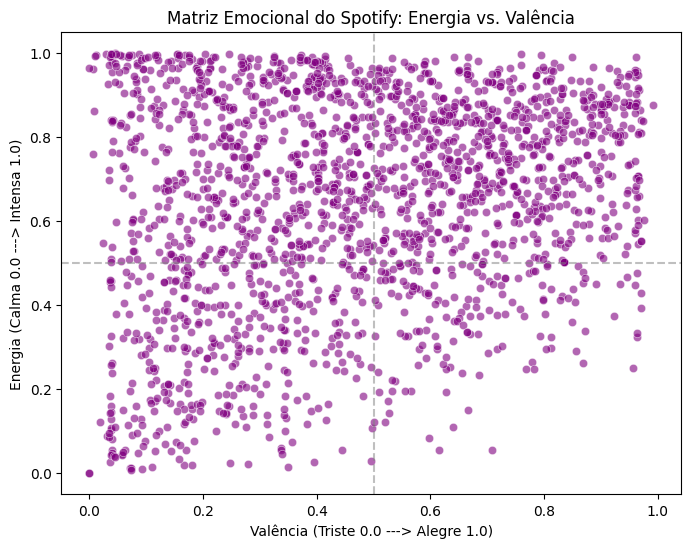

In [21]:
df_amostra = df.sample(n=2000, random_state=42)

plt.figure(figsize=(8, 6))

sns.scatterplot(data=df_amostra, x='valence', y='energy', alpha=0.6, color='purple')

plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.title('Matriz Emocional do Spotify: Energia vs. Valência')
plt.xlabel('Valência (Triste 0.0 ---> Alegre 1.0)')
plt.ylabel('Energia (Calma 0.0 ---> Intensa 1.0)')
plt.show()

### Descobrindo os artistas mais presentes

Nessa investigação, iremos descobrir quais artistas possuem mais faixas no dataset e a média da sua popularidade. 
Para realizar essa consulta, iremos calcular a média da popularidade dos artistas de acordo com a popularidade das suas faixas.

In [31]:
df_artistas = df.groupby('artists')['popularity'].agg(['count', 'mean'])

df_artistas = df_artistas.rename(columns={'count': 'total_musicas', 'mean': 'popularidade_media'})

top_10_frequentes = df_artistas.sort_values(by='total_musicas', ascending=False).head(10)

top_10_frequentes['popularidade_media'] = top_10_frequentes['popularidade_media'].round(1)

Com o top 10 dos artistas, pode concluir que:
1. Artistas mais clássicos possuem uma frequência maior no dataset.
2. O número de faixas não dita a popularidade. É possível observar artistas com um alto volume de faixas, mas com popularidade baixa.

In [32]:
print("Top 10 artistas mais frequentes:")
print(top_10_frequentes)

Top 10 artistas mais frequentes:
                 total_musicas  popularidade_media
artists                                           
The Beatles                279                61.0
George Jones               271                16.5
Stevie Wonder              236                 1.1
Linkin Park                224                56.1
Ella Fitzgerald            222                 0.7
Prateek Kuhad              217                46.3
Feid                       202                10.1
Chuck Berry                190                 7.9
Håkan Hellström            183                31.5
OneRepublic                181                30.9


### Entendendo a correlação da popularidade com a energia e valência da música

Pelo gráfico, é possível concluir que a energia (energy) e a valência (valence) não ditam a popularidade de uma música de forma isolada.
Provavelmente, questões como fanbase do artista, vriais em redes sociais (Instagram, TikTok), ou o marketing por parte da gravadora, são fatores externos que podem indicar a popularidade de uma música.

📊 MATRIZ DE CORRELAÇÃO (NUMÉRICA):
            popularity  energy  valence
popularity       1.000   0.001   -0.041
energy           0.001   1.000    0.259
valence         -0.041   0.259    1.000


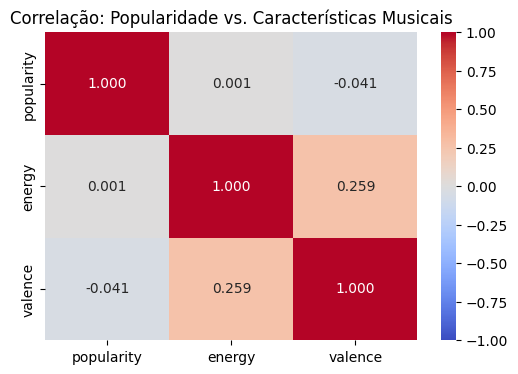

In [33]:
df_correlacao = df[['popularity', 'energy', 'valence']]

matriz = df_correlacao.corr()
print("📊 MATRIZ DE CORRELAÇÃO (NUMÉRICA):")
print(matriz.round(3))

plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title('Correlação: Popularidade vs. Características Musicais')
plt.show()